Fetching intraday data for ['AAPL', 'MSFT', 'NVDA', 'GOOGL'] from Yahoo Finance...


[*********************100%***********************]  4 of 4 completed
g:\Programs\Python\Python314\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



--- Training Model ---
Epoch 01/15 | Train Sharpe Loss: -0.026566
Epoch 02/15 | Train Sharpe Loss: -0.019107
Epoch 03/15 | Train Sharpe Loss: 0.004262
Epoch 04/15 | Train Sharpe Loss: -0.030191
Epoch 05/15 | Train Sharpe Loss: -0.003630
Epoch 06/15 | Train Sharpe Loss: -0.041490
Epoch 07/15 | Train Sharpe Loss: -0.014616
Epoch 08/15 | Train Sharpe Loss: -0.009475
Epoch 09/15 | Train Sharpe Loss: -0.017246
Epoch 10/15 | Train Sharpe Loss: -0.029317
Epoch 11/15 | Train Sharpe Loss: -0.014228
Epoch 12/15 | Train Sharpe Loss: -0.007406
Epoch 13/15 | Train Sharpe Loss: -0.028722
Epoch 14/15 | Train Sharpe Loss: -0.012284
Epoch 15/15 | Train Sharpe Loss: -0.018332

--- Out-of-Sample Backtesting (MC Dropout) ---
[Equal Weight] Ann. Return: 31.62% | Sharpe: 1.7143
[Attention TCN] Ann. Return: 97.12% | Sharpe: 4.0225
[Bayesian Shrinkage TCN] Ann. Return: 94.32% | Sharpe: 4.0823


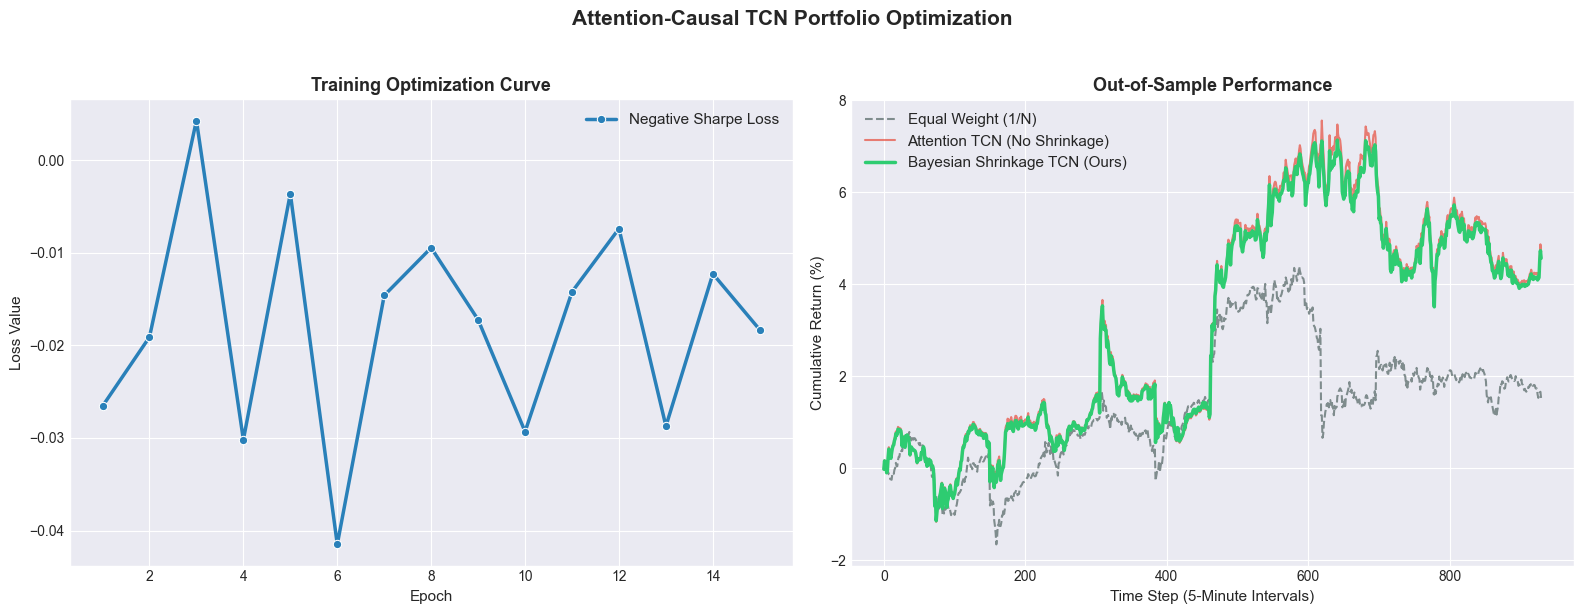

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.utils as utils
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# ==========================================
# 1. ATTENTION-ENHANCED CAUSAL TCN DEFINITION
# ==========================================

class Chomp1d(nn.Module):
    """Slices off padding from the right side of the sequence to ensure causality."""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    """Causal, dilated 1D convolutional block with Weight Normalization and Dropout."""
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = utils.weight_norm(
            nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = utils.weight_norm(
            nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class SelfAttention(nn.Module):
    """Self-attention block to capture global cross-asset dependencies."""
    def __init__(self, embed_dim, num_heads=2):
        super(SelfAttention, self).__init__()
        self.mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.layernorm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.mha(x, x, x)
        return self.layernorm(x + attn_out)


class AttentionTCNPortfolioModel(nn.Module):
    """Deep Portfolio model returning asset allocation weights."""
    def __init__(self, num_assets, num_channels=[16, 32, 64], kernel_size=3, dropout=0.2):
        super(AttentionTCNPortfolioModel, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_assets if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, 
                                     dilation=dilation_size, padding=padding, dropout=dropout)]

        self.tcn = nn.Sequential(*layers)
        self.attention = SelfAttention(embed_dim=num_channels[-1])
        self.fc = nn.Linear(num_channels[-1], num_assets)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        tcn_out = self.tcn(x)                  # [batch_size, num_channels[-1], sequence_length]
        tcn_out = tcn_out.transpose(1, 2)      # [batch_size, sequence_length, num_channels[-1]]
        
        attn_out = self.attention(tcn_out)      # [batch_size, sequence_length, num_channels[-1]]
        last_step = attn_out[:, -1, :]         # Extract last temporal representation
        
        logits = self.fc(last_step)            # [batch_size, num_assets]
        weights = self.softmax(logits)         # Sum-to-one constraint and long-only weights
        return weights


# ==========================================
# 2. DIFFERENTIABLE NEGATIVE SHARPE LOSS
# ==========================================

class NegativeSharpeRatioLoss(nn.Module):
    """Differentiable loss function to maximize portfolio Sharpe Ratio."""
    def __init__(self, eps=1e-8, risk_free_rate=0.0):
        super(NegativeSharpeRatioLoss, self).__init__()
        self.eps = eps
        self.risk_free_rate = risk_free_rate

    def forward(self, weights, raw_returns):
        portfolio_returns = torch.sum(weights * raw_returns, dim=1)  # [batch_size]
        mean_return = torch.mean(portfolio_returns)
        std_return = torch.std(portfolio_returns)
        
        # Minimize Negative Sharpe to maximize Sharpe Ratio
        sharpe_ratio = (mean_return - self.risk_free_rate) / (std_return + self.eps)
        return -sharpe_ratio


# ==========================================
# 3. ROBUST DATA ACQUISITION & PREPROCESSING
# ==========================================

def fetch_and_preprocess_data(tickers, period="60d", interval="5m", lookback=30):
    """Downloads intraday data, extracts returns, standardizes features, and handles 'Adj Close' checks."""
    print(f"Fetching intraday data for {tickers} from Yahoo Finance...")
    raw_data = yf.download(tickers, period=period, interval=interval, group_by='ticker')
    
    prices = pd.DataFrame()
    for t in tickers:
        ticker_df = raw_data[t]
        # ROBUST FALLBACK TO PREVENT KEYERROR ON INTRADAY PRICE DATA
        if 'Adj Close' in ticker_df.columns:
            prices[t] = ticker_df['Adj Close']
        else:
            prices[t] = ticker_df['Close']
            
    prices = prices.dropna()
    returns = prices.pct_change().dropna()
    
    # Feature Scaling: Standardize returns to stabilize gradients (avoid future lookahead leak)
    mean = returns.mean()
    std = returns.std()
    norm_returns = (returns - mean) / (std + 1e-8)
    
    X, Y = [], []
    norm_values = norm_returns.values
    raw_values = returns.values
    
    # Generate temporal causal sequence windows
    for i in range(len(returns) - lookback):
        X.append(norm_values[i : i + lookback].T)  # Shape: [num_assets, sequence_length]
        Y.append(raw_values[i + lookback])         # Target raw returns
        
    X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
    Y_tensor = torch.tensor(np.array(Y), dtype=torch.float32)
    
    return X_tensor, Y_tensor, returns


# ==========================================
# 4. TRAINING, EVALUATION, AND PLOTTING
# ==========================================

def run_pipeline():
    tickers = ["AAPL", "MSFT", "NVDA", "GOOGL"]
    lookback = 30
    batch_size = 128
    epochs = 15
    
    X, Y, raw_returns_df = fetch_and_preprocess_data(tickers, period="60d", interval="5m", lookback=lookback)
    
    # Temporal Split to prevent historical chronological leakage
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]
    
    train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = AttentionTCNPortfolioModel(num_assets=len(tickers))
    criterion = NegativeSharpeRatioLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # Training Loop
    print("\n--- Training Model ---")
    train_losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            weights = model(batch_x)
            loss = criterion(weights, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Sharpe Loss: {avg_loss:.6f}")
        
    # Bayesian Evaluation with MC Dropout Active
    print("\n--- Out-of-Sample Backtesting (MC Dropout) ---")
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()  # Keep dropout active during evaluation
            
    num_samples = 30
    mc_weights = []
    
    with torch.no_grad():
        for _ in range(num_samples):
            pred_w = model(X_test)
            mc_weights.append(pred_w.unsqueeze(0))
            
    mc_weights = torch.cat(mc_weights, dim=0)  # Shape: [num_samples, test_samples, num_assets]
    mean_weights = torch.mean(mc_weights, dim=0).numpy()
    var_weights = torch.var(mc_weights, dim=0).numpy()
    
    # Apply Bayesian Shrinkage towards Equal Weight portfolio when uncertainty is high
    uncertainty = np.mean(var_weights, axis=1)
    min_u, max_u = np.min(uncertainty), np.max(uncertainty)
    lambda_shrink = 0.85 * (uncertainty - min_u) / (max_u - min_u + 1e-8)
    lambda_shrink = pd.Series(lambda_shrink).rolling(window=10, min_periods=1).mean().values
    lambda_shrink = lambda_shrink[:, np.newaxis]
    
    eq_weights = np.ones_like(mean_weights) / len(tickers)
    bayesian_weights = (1 - lambda_shrink) * mean_weights + lambda_shrink * eq_weights
    bayesian_weights = bayesian_weights / np.sum(bayesian_weights, axis=1, keepdims=True)
    
    # Cumulative Return Calculations
    Y_test_np = Y_test.numpy()
    portfolio_tcn_returns = np.sum(mean_weights * Y_test_np, axis=1)
    portfolio_bayesian_returns = np.sum(bayesian_weights * Y_test_np, axis=1)
    portfolio_eq_returns = np.sum(eq_weights * Y_test_np, axis=1)
    
    cum_eq = (np.exp(np.cumsum(portfolio_eq_returns)) - 1) * 100
    cum_tcn = (np.exp(np.cumsum(portfolio_tcn_returns)) - 1) * 100
    cum_bayesian = (np.exp(np.cumsum(portfolio_bayesian_returns)) - 1) * 100
    
    # Print out performance summary
    annual_factor = np.sqrt(252 * 78)
    def show_metrics(ret, label):
        m_r = np.mean(ret)
        s_r = np.std(ret)
        print(f"[{label}] Ann. Return: {m_r * 252 * 78 * 100:.2f}% | Sharpe: {(m_r / (s_r + 1e-8)) * annual_factor:.4f}")
        
    show_metrics(portfolio_eq_returns, "Equal Weight")
    show_metrics(portfolio_tcn_returns, "Attention TCN")
    show_metrics(portfolio_bayesian_returns, "Bayesian Shrinkage TCN")

    # ==========================================
    # 5. VISUALIZATION OF OUTCOMES
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    # Panel 1: Training Loss Curve
    sns.lineplot(x=range(1, epochs + 1), y=train_losses, ax=axes[0], color="#2980b9", marker="o", linewidth=2.5, label="Negative Sharpe Loss")
    axes[0].set_title("Training Optimization Curve", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Loss Value", fontsize=11)
    axes[0].legend(loc="upper right")

    # Panel 2: Out-of-Sample Backtesting Performance
    axes[1].plot(cum_eq, label="Equal Weight (1/N)", color="#7f8c8d", linestyle="--", linewidth=1.5)
    axes[1].plot(cum_tcn, label="Attention TCN (No Shrinkage)", color="#e74c3c", alpha=0.7, linewidth=1.5)
    axes[1].plot(cum_bayesian, label="Bayesian Shrinkage TCN (Ours)", color="#2ecc71", linewidth=2.5)
    axes[1].set_title("Out-of-Sample Performance", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Time Step (5-Minute Intervals)", fontsize=11)
    axes[1].set_ylabel("Cumulative Return (%)", fontsize=11)
    axes[1].legend(loc="upper left")

    plt.suptitle("Attention-Causal TCN Portfolio Optimization", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_pipeline()
